In [3]:
import os
import sys
import re
sys.path.append('..')

In [4]:
gals = sorted(set([a.split('_')[0] for a in os.listdir('fits')]))
gals


['Au1', 'Au15', 'Au16', 'Au19', 'Au3']

In [5]:
def parse_break_file(filepath):
    """
    Парсинг одного файла break_*.dat от pyimfit.
    
    Parameters
    ----------
    filepath : str
        Путь к файлу.
    
    Returns
    -------
    dict : словарь с параметрами и статистиками.
    """
    params = {}
    
    with open(filepath, 'r') as f:
        content = f.read()
    
    lines = content.strip().split('\n')
    current_function = None
    current_label = None
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        
        # Определяем текущую функцию и её метку
        if line.upper().startswith('FUNCTION'):
            func_match = re.search(r'FUNCTION\s+(\w+)', line, re.IGNORECASE)
            label_match = re.search(r'LABEL\s+(\w+)', line, re.IGNORECASE)
            
            if func_match:
                current_function = func_match.group(1)
            if label_match:
                current_label = label_match.group(1)
            continue
        
        # Парсим параметры функций (с погрешностями в комментариях)
        # Формат: "I_e  8.861445525221225  # +/- 0.5660627957355975"
        param_match = re.match(r'(\w+)\s+([\d.eE+\-]+)\s*#\s*\+\/-\s*([\d.eE+\-]+)', line)
        if param_match and current_function and current_label:
            param_name = param_match.group(1)
            param_value = float(param_match.group(2))
            param_error = float(param_match.group(3))
            
            # Формируем имя параметра: label_param
            full_param_name = f"{current_label}_{param_name}"
            params[full_param_name] = param_value
            params[f"{full_param_name}_err"] = param_error
            continue
        
        # Парсим общие параметры модели (X0, Y0) с погрешностями
        common_match = re.match(r'(X0|Y0)\s+([\d.eE+\-]+)\s*#\s*\+\/-\s*([\d.eE+\-]+)', line, re.IGNORECASE)
        if common_match:
            param_name = common_match.group(1)
            param_value = float(common_match.group(2))
            param_error = float(common_match.group(3))
            params[param_name] = param_value
            params[f"{param_name}_err"] = param_error
            continue
        
        # Парсим статистики фита (строки вида "solverName LM", "fitConverged True")
        # Ищем строки без комментариев с ключом и значением
        stat_match = re.match(r'(\w+)\s+([\w.+\-]+)\s*$', line)
        if stat_match and '#' not in line:
            key = stat_match.group(1)
            value = stat_match.group(2)
            
            try:
                # Пробуем преобразовать в число
                if '.' in value or 'e' in value.lower():
                    params[key] = float(value)
                else:
                    params[key] = int(value)
            except ValueError:
                # Для булевых значений и строк
                if value == 'True':
                    params[key] = True
                elif value == 'False':
                    params[key] = False
                else:
                    params[key] = value
            continue
        
        # Парсим статистики с числами (fitStat, AIC, BIC)
        stat_num_match = re.match(r'(\w+)\s+([\d.eE+\-]+)\s*$', line)
        if stat_num_match and '#' not in line:
            key = stat_num_match.group(1)
            try:
                value = float(stat_num_match.group(2))
                params[key] = value
            except ValueError:
                pass
    
    # Добавляем имя файла для идентификации
    params['filename'] = os.path.basename(filepath)
    
    # Переименовываем статистики в стандартные названия
    stats_mapping = {
        'fitStat': 'fitStat',
        'fitStatReduced': 'chi2',
        'aic': 'AIC',
        'bic': 'BIC',
        'fitConverged': 'fitConverged',
        'nIter': 'nIter',
        'nFuncEvals': 'nFuncEvals',
        'solverName': 'solverName',
    }
    
    # Создаем копии с правильными именами
    for old_name, new_name in stats_mapping.items():
        if old_name in params:
            params[new_name] = params[old_name]
    
    return params

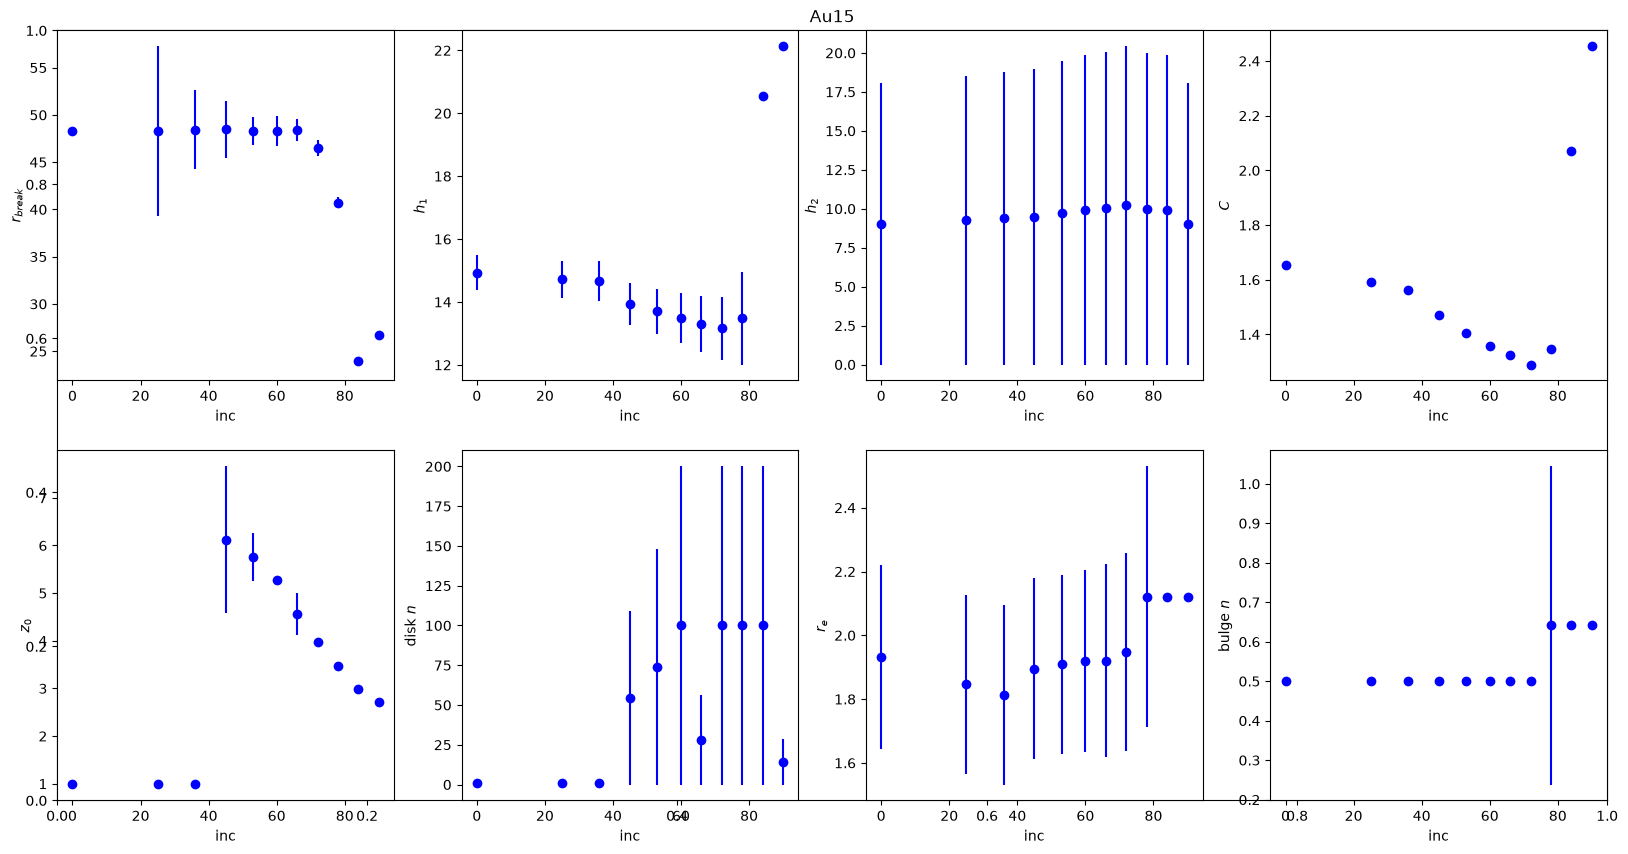

In [6]:

from matplotlib import pyplot as plt

for gal in ['Au15']:
    plt.figure(figsize=(20,10))
    plt.title(gal)
    for i in [0, 25,36, 45, 53, 60,66,72,78,84,90]:
        file = f'fits/{gal}_i{i}/best_clustered.dat'
        file_parse = parse_break_file(file)
        plt.subplot(241)
        plt.errorbar(i, file_parse['disk_r_break'], yerr=file_parse['disk_r_break_err'], fmt='ob')
        plt.xlabel('inc')
        plt.ylabel(r'$r_{break}$')
        plt.subplot(242)
        plt.errorbar(i, file_parse['disk_h1'],yerr=file_parse['disk_h1_err'],  fmt='ob')
        plt.xlabel('inc')
        plt.ylabel(r'$h_1$')


        plt.subplot(243)
        plt.errorbar(i, file_parse['disk_h2'], yerr=file_parse['disk_h2'], fmt='ob')
        plt.xlabel('inc')
        plt.ylabel(r'$h_2$')


        plt.subplot(244)
        plt.errorbar(i, file_parse['disk_h1']/file_parse['disk_h2'], fmt='ob')
        plt.xlabel('inc')
        plt.ylabel(r'$C$')


        plt.subplot(245)
        plt.errorbar(i, file_parse['disk_z_0'], yerr=file_parse['disk_z_0_err'], fmt='ob')
        plt.xlabel('inc')
        plt.ylabel(r'$z_0$')


        plt.subplot(246)
        plt.errorbar(i, file_parse['disk_n'], yerr=file_parse['disk_n'], fmt='ob')
        plt.xlabel('inc')
        plt.ylabel(r'disk $n$')


        plt.subplot(247)
        plt.errorbar(i, file_parse['bulge_r_e'], yerr=file_parse['bulge_r_e_err'], fmt='ob')
        plt.xlabel('inc')
        plt.ylabel(r'$r_e$')

        
        plt.subplot(248)
        plt.errorbar(i, file_parse['bulge_n'], yerr=file_parse['bulge_n_err'], fmt='ob')
        plt.xlabel('inc')
        plt.ylabel(r'bulge $n$')

        
        

    break
        #print(file, file['r_break'])
plt.show()

0.9999999999999999
9.993246561751738
93.75901263911831



*** ReadConfigFile: Bad parameter specification at line 18 in configuration file!
    (Parameter line should be: name, then initial numerical value (+ optionally "fixed" OR lower,upper numerical limits)

*** ERROR: Failure reading configuration file "/home/android/eagle/profile_v3/final_fit/917940/917940_28.dat"!

/tmp/ipykernel_311635/3725687294.py:42: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e6[250,:]), '-', label='1e6' )
/tmp/ipykernel_311635/3725687294.py:43: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e5[250,:]), '-', label='1e5' )
/tmp/ipykernel_311635/3725687294.py:44: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e4[250,:]), '-', label='1e4' )
/tmp/ipykernel_311635/3725687294.py:45: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e3

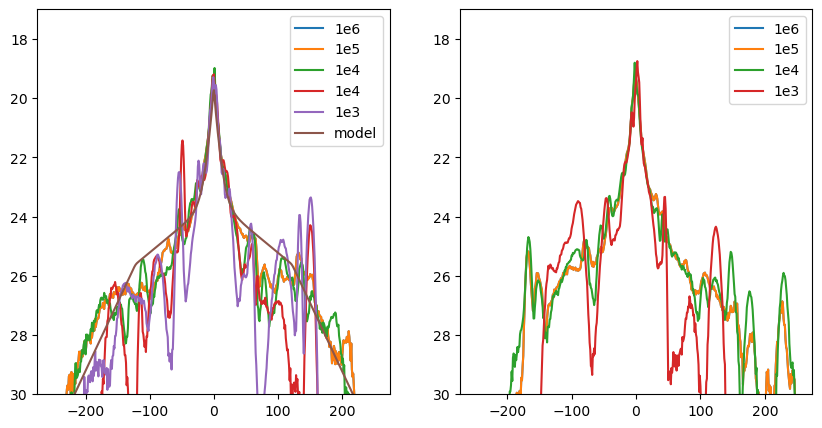

Radius: 1.03/250.00
Radius: 1.06/250.00
Radius: 1.09/250.00
Radius: 1.13/250.00
Radius: 1.16/250.00
Radius: 1.19/250.00
Radius: 1.23/250.00
Radius: 1.27/250.00
Radius: 1.30/250.00
Radius: 1.34/250.00
Radius: 1.38/250.00
Radius: 1.43/250.00
Radius: 1.47/250.00
Radius: 1.51/250.00
Radius: 1.56/250.00
Radius: 1.60/250.00
Radius: 1.65/250.00
Radius: 1.70/250.00
Radius: 1.75/250.00
Radius: 1.81/250.00
Radius: 1.86/250.00
Radius: 1.92/250.00
Radius: 1.97/250.00
Radius: 2.03/250.00
Radius: 2.09/250.00
Radius: 2.16/250.00
Radius: 2.22/250.00
Radius: 2.29/250.00
Radius: 2.36/250.00
Radius: 2.43/250.00
Radius: 2.50/250.00
Radius: 2.58/250.00
Radius: 2.65/250.00
Radius: 2.73/250.00
Radius: 2.81/250.00
Radius: 2.90/250.00
Radius: 2.99/250.00
Radius: 3.07/250.00
Radius: 3.17/250.00
Radius: 3.26/250.00
Radius: 3.36/250.00
Radius: 3.46/250.00
Radius: 3.56/250.00
Radius: 3.67/250.00
Radius: 3.78/250.00
Radius: 3.90/250.00
Radius: 4.01/250.00
Radius: 4.13/250.00
Radius: 4.26/250.00
Radius: 4.38/250.00


/usr/lib/python3/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/lib/python3/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Radius: 16.10/250.00
Radius: 16.58/250.00
Radius: 17.08/250.00
Radius: 17.59/250.00
Radius: 18.12/250.00
Radius: 18.66/250.00
Radius: 19.22/250.00
Radius: 19.80/250.00
Radius: 20.39/250.00
Radius: 21.00/250.00
Radius: 21.63/250.00
Radius: 22.28/250.00
Radius: 22.95/250.00
Radius: 23.64/250.00
Radius: 24.35/250.00
Radius: 25.08/250.00
Radius: 25.83/250.00
Radius: 26.60/250.00
Radius: 27.40/250.00
Radius: 28.22/250.00
Radius: 29.07/250.00
Radius: 29.94/250.00
Radius: 30.84/250.00
Radius: 31.77/250.00
Radius: 32.72/250.00
Radius: 34.20/250.00
Radius: 35.21/250.00
Radius: 36.25/250.00
Radius: 37.32/250.00
Radius: 38.43/250.00
Radius: 39.57/250.00
Radius: 40.74/250.00
Radius: 41.95/250.00
Radius: 43.19/250.00
Radius: 44.47/250.00
Radius: 45.79/250.00
Radius: 47.15/250.00
Radius: 48.55/250.00
Radius: 49.99/250.00
Radius: 51.47/250.00
Radius: 53.00/250.00
Radius: 54.58/250.00
Radius: 56.20/250.00
Radius: 57.87/250.00
Radius: 59.59/250.00
Radius: 61.37/250.00
Radius: 63.19/250.00
Radius: 65.07

/usr/lib/python3/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/lib/python3/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Radius: 19.22/250.00
Radius: 19.80/250.00
Radius: 20.39/250.00
Radius: 21.00/250.00
Radius: 21.63/250.00
Radius: 22.28/250.00
Radius: 22.95/250.00
Radius: 23.64/250.00
Radius: 24.35/250.00
Radius: 25.08/250.00
Radius: 25.83/250.00
Radius: 26.60/250.00
Radius: 27.40/250.00
Radius: 28.22/250.00
Radius: 29.07/250.00
Radius: 29.94/250.00
Radius: 30.84/250.00
Radius: 31.77/250.00
Radius: 32.72/250.00
Radius: 34.20/250.00
Radius: 35.21/250.00
Radius: 36.25/250.00
Radius: 37.32/250.00
Radius: 38.43/250.00
Radius: 39.57/250.00
Radius: 40.74/250.00
Radius: 41.95/250.00
Radius: 43.19/250.00
Radius: 44.47/250.00
Radius: 45.79/250.00
Radius: 47.15/250.00
Radius: 48.55/250.00
Radius: 49.99/250.00
Radius: 51.47/250.00
Radius: 53.00/250.00
Radius: 54.58/250.00
Radius: 56.20/250.00
Radius: 57.87/250.00
Radius: 59.59/250.00
Radius: 61.37/250.00
Radius: 63.19/250.00
Radius: 65.07/250.00
Radius: 67.01/250.00
Radius: 69.51/250.00
Radius: 71.56/250.00
Radius: 73.68/250.00
Radius: 75.86/250.00
Radius: 78.10

...

/usr/lib/python3/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/lib/python3/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Radius: 5.55/250.00
Radius: 5.72/250.00
Radius: 5.89/250.00
Radius: 6.07/250.00
Radius: 6.25/250.00
Radius: 6.44/250.00
Radius: 6.63/250.00
Radius: 6.83/250.00
Radius: 7.03/250.00
Radius: 7.25/250.00
Radius: 7.46/250.00
Radius: 7.69/250.00
Radius: 7.92/250.00
Radius: 8.16/250.00
Radius: 8.40/250.00
Radius: 8.65/250.00
Radius: 8.91/250.00
Radius: 9.18/250.00
Radius: 9.45/250.00
Radius: 9.74/250.00
Radius: 10.03/250.00
Radius: 10.33/250.00
Radius: 10.64/250.00
Radius: 10.96/250.00
Radius: 11.29/250.00
Radius: 11.63/250.00
Radius: 11.98/250.00
Radius: 12.34/250.00
Radius: 12.71/250.00
Radius: 13.09/250.00
Radius: 13.48/250.00
Radius: 13.88/250.00
Radius: 14.30/250.00
Radius: 14.73/250.00
Radius: 15.17/250.00
Radius: 15.63/250.00
Radius: 16.10/250.00
Radius: 16.58/250.00
Radius: 17.08/250.00
Radius: 17.59/250.00
Radius: 18.12/250.00
Radius: 18.66/250.00
Radius: 19.22/250.00
Radius: 19.80/250.00
Radius: 20.39/250.00
Radius: 21.00/250.00
Radius: 21.63/250.00
Radius: 22.28/250.00
Radius: 22.9

/usr/lib/python3/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/lib/python3/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Radius: 16.58/250.00
Radius: 17.08/250.00
Radius: 17.59/250.00
Radius: 18.12/250.00
Radius: 18.66/250.00
Radius: 19.22/250.00
Radius: 19.80/250.00
Radius: 20.39/250.00
Radius: 21.00/250.00
Radius: 21.63/250.00
Radius: 22.28/250.00
Radius: 22.95/250.00
Radius: 23.64/250.00
Radius: 24.35/250.00
Radius: 25.08/250.00
Radius: 25.83/250.00
Radius: 26.60/250.00
Radius: 27.40/250.00
Radius: 28.22/250.00
Radius: 29.07/250.00
Radius: 29.94/250.00
Radius: 30.84/250.00
Radius: 31.77/250.00
Radius: 32.72/250.00
Radius: 34.20/250.00
Radius: 35.21/250.00
Radius: 36.25/250.00
Radius: 37.32/250.00
Radius: 38.43/250.00
Radius: 39.57/250.00
Radius: 40.74/250.00
Radius: 41.95/250.00
Radius: 43.19/250.00
Radius: 44.47/250.00
Radius: 45.79/250.00
Radius: 47.15/250.00
Radius: 48.55/250.00
Radius: 49.99/250.00
Radius: 51.47/250.00
Radius: 53.00/250.00
Radius: 54.58/250.00
Radius: 56.20/250.00
Radius: 57.87/250.00
Radius: 59.59/250.00
Radius: 61.37/250.00
Radius: 63.19/250.00
Radius: 65.07/250.00
Radius: 67.01

/usr/lib/python3/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/lib/python3/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/lib/python3/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


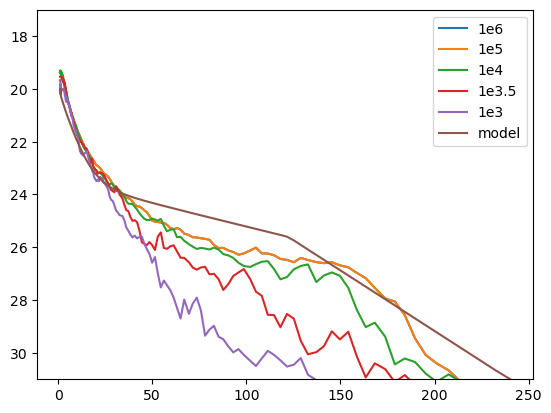

In [ ]:
from astropy.io import fits
import numpy as np
from bin.common_functions import AB_mag
import subprocess as sp

sys.path.append('/home/android/iman_new/iraf_fitting')
sys.path.append('/home/android/iman_new/Ellipse_photometry')

from azimProfile import main as azimp # type: ignore


zp = 8.9 - 2.5*np.log10(AB_mag(1))
i = 31
data_1e6 = fits.getdata(f'/home/android/Eagle/Results/g-0000/r-0000-0{i}/in/1e5_sdss_r.fits')
data_1e5 = fits.getdata(f'/home/android/Eagle/Results/g-0000/r-0000-0{i}/in/1e5_sdss_r.fits')
data_1e4 = fits.getdata(f'/home/android/Eagle/Results/g-0000/r-0000-0{i}/in/1e4_sdss_r.fits')
data_1e3_5 = fits.getdata(f'/home/android/Eagle/Results/g-0000/r-0000-0{i}/in/1e3.5_sdss_r.fits')
data_1e3 = fits.getdata(f'/home/android/Eagle/Results/g-0000/r-0000-0{i}/in/1e3_sdss_r.fits')

tot_1e6 = np.sum(data_1e6)
tot_1e5 = np.sum(data_1e5)
tot_1e4 = np.sum(data_1e4)
tot_1e3 = np.sum(data_1e3)
tot_1e3_5 = np.sum(data_1e3_5)

print(1/tot_1e5*tot_1e6)
print(1/tot_1e4*tot_1e6)
print(1/tot_1e3*tot_1e6)

data_1e5 = data_1e5/tot_1e5*tot_1e6
data_1e4 = data_1e4/tot_1e4*tot_1e6
data_1e3 = data_1e3/tot_1e3*tot_1e6
data_1e3_5 = data_1e3_5/tot_1e3_5*tot_1e6

sp.call(f'makeimage18 /home/android/eagle/profile_v3/final_fit/917940/917940_28.dat --refimage=azi_data.fits', shell=True)
model = fits.getdata('modelimage.fits')

model = model/np.sum(model) * tot_1e6

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e6[250,:]), '-', label='1e6' )
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e5[250,:]), '-', label='1e5' )
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e4[250,:]), '-', label='1e4' )
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e3_5[250,:]), '-', label='1e4' )
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e3[250,:]), '-', label='1e3' )
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(model[250,:]), '-', label='model' )
plt.gca().invert_yaxis()
plt.ylim(30, 17)
plt.legend()

plt.subplot(122)
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e6[:, 250]), '-', label='1e6' )
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e5[:,250]), '-', label='1e5' )
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e4[:,250]), '-', label='1e4' )
plt.plot(np.arange(500)-250, zp - 2.5*np.log10(data_1e3[:,250]), '-', label='1e3' )
plt.gca().invert_yaxis()
plt.ylim(30, 17)
plt.legend()
plt.show()

labels = ['1e6', '1e5', '1e4', '1e3.5', '1e3', 'model']
for i, data in enumerate([data_1e6, data_1e5, data_1e4, data_1e3_5, data_1e3, model]):

    fits.writeto('azi_data.fits', data, overwrite=True)

    mask = np.zeros(data.shape)
    mask[data<=0] = 1
    fits.writeto('azi_mask.fits', mask, overwrite=True)

    output_model = None
    azim_tab = 'azim.txt'
    mask_image = 'azi_mask.fits'
    posang = 0
    ellip    = 0
    xcen = 250
    ycen = 250
    sma_min = 1
    sma_max = 250
    sigma_sky = None
    sigma_cal = None
    outside_frame = False
    step = 0.03
    linear = False
    #if not(os.path.exists(azim_tab)):
    azimp('azi_data.fits', output_model, 
        azim_tab, mask_image, xcen, ycen, 
        ellip, posang, sma_min, sma_max, step, 
        sigma_sky, sigma_cal, 
        outside_frame=outside_frame, linear=linear)
    sma_0, flux_0, flux_err_0 = np.loadtxt('azim.txt', skiprows=1, unpack=True)
    plt.plot(sma_0, zp-2.5*np.log10(flux_0), '-', label=labels[i])
plt.gca().invert_yaxis()
plt.ylim(40,17)
plt.legend()
plt.show()